<a href="https://colab.research.google.com/github/suwabe-j/practice-project/blob/main/chapter6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

         x0        x1        x2        x3      target
0  1.000943  2.114344 -1.148213 -0.051415   77.147293
1  1.505901 -0.626081  3.041686 -0.587336  278.595852
2 -0.390320  0.283607 -0.940359 -2.154124  -71.039904
x0         True
x1        False
x2         True
x3        False
target    False
dtype: bool
決定定数が0.9871512483922387なので性能がいい


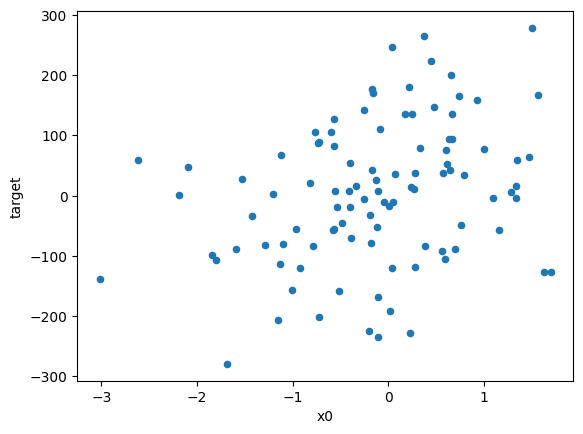

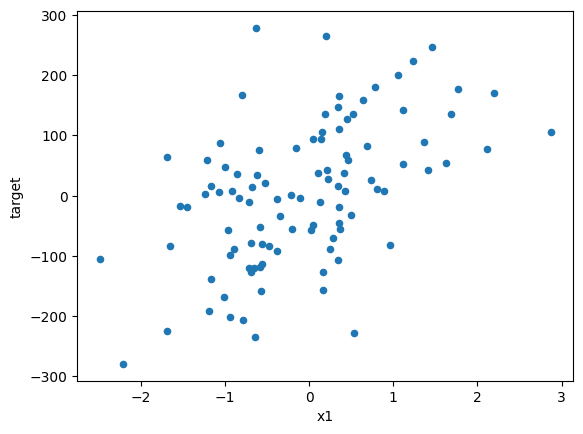

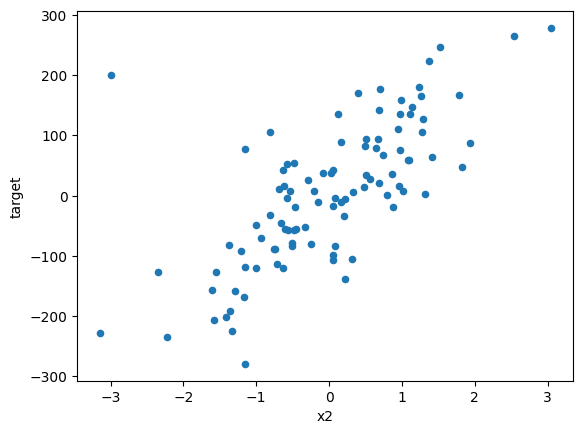

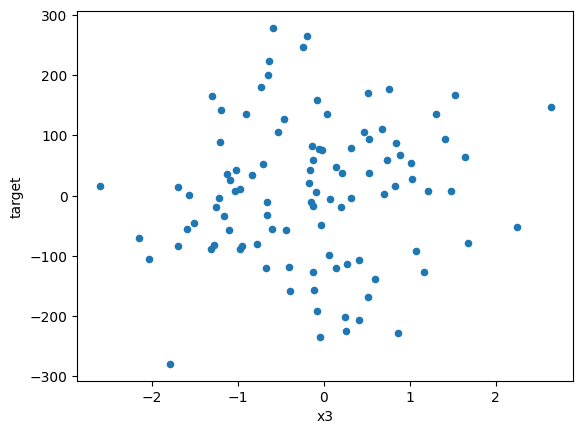

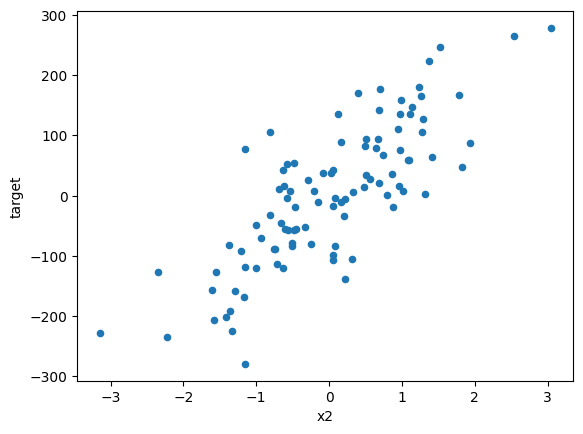

In [16]:
# pandasをインポート
import pandas as pd

# ex3をインポート
ex3_csv = pd.read_csv("ex3.csv")

# 先頭（head）３行を表示
print(ex3_csv.head(3))

# 欠損値の確認（isnullでnullを探す、anyで１つでもnullの条件、axis０で縦）
print(ex3_csv.isnull().any(axis=0))

# 欠損値の保管（中央値で）
ex3_csv["x0"] = ex3_csv["x0"].fillna(ex3_csv["x0"].median())
ex3_csv["x2"] = ex3_csv["x2"].fillna(ex3_csv["x2"].median())

# 散布図の作成
# わざわざカラムのリストを作るのは嫌なのでカラム集でforを回す
for x_axis in ex3_csv.columns:
  # 散布図のx軸とy軸が同じになるのはNGなので避ける
  if x_axis != "target":
    ex3_csv.plot(kind="scatter", x=x_axis, y="target")
  # 同じの場合は何もせずに次のforへ
  else:
    continue

# x軸のx2の散布図に明らかなハズレ値があるのでそれを排除する
# ハズレ値のインデックス（行数）を抽出する
outlier = ex3_csv[(ex3_csv["x2"]<-2)&(ex3_csv["target"]>100)].index
#抽出したインデックスの値を排除する
new_ex3_csv = ex3_csv.drop(outlier, axis=0)
# ハズレ値が排除されているか見てみる
new_ex3_csv.plot(kind="scatter", x="x2", y="target")

# 特徴量と正解データを分けるクラスのmodel_selectionをインポート
from sklearn.model_selection import train_test_split

# x0〜x3を特徴量、targetを正解データとする
feature = new_ex3_csv.loc[ : , "x0":"x3"]
target = new_ex3_csv.loc[ : , "target"]

# テストデータは20%、乱数シード（スタート地点）は１とする
x_train, x_test, y_train, y_test = train_test_split(feature, target,
                                                     test_size=0.3 , random_state = 1)

# 重回帰モデル（LinerRegression）で学習したいのでインポート
from sklearn.linear_model import LinearRegression
# 重回帰分析ではランダムに何かをするということがないので乱数シードはなし
Liner_model = LinearRegression()
# 訓練（training）データ学習させる
Liner_model.fit(x_train, y_train)
# 平均絶対誤差は正解データの専門知識ないとデータの良し悪しがわからないので決定係数を使用
r_squared = Liner_model.score(x_test, y_test)
if r_squared >= 0.8:
  print(f"決定定数が{r_squared}なので性能がいい")
else:
  print(f"決定係数が{r_squared}なので性能が悪い")


